#### DL - End-to-End Regression Project
- Topic: Full ML pipeline, EDA, Feature Engineering, MLP Regression, Hyperparameter search, Deployement-ready model. 
- Predict Automobile Fuel Efficiency (MPG)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import tensorflow as tf
    from tensorflow import keras
    TF_AVAILABLE = True
    print(f"TensorFlow {tf.__version__} | numpy{np.__version__}")
except ImportError:
    TF_AVAILABLE = False
    print("Tensorflow not available")



TensorFlow 2.21.0 | numpy2.3.5


Step 1: Problem Definition & Data Loading

In [2]:
print('PROJECT: AUTOMOBILE FUEL EFFICIENCY PREDICTION')
print('='*55)
print('Task: Predict MPG (miles per gallon) from car specs')
print('Type: Regression (continuous target variable)')
print('Metric: RMSE (root mean squared error)')
print()

# Auto MPG dataset (UCI)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
col_names = ['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year','origin','car_name']

try:
    df = pd.read_csv(url, names=col_names, na_values='?', comment='\t', sep=' ', skipinitialspace=True)
    print(f'Dataset loaded from URL: {df.shape}')
except:
    # Fallback: generate synthetic similar data
    np.random.seed(42)
    n = 400
    cylinders     = np.random.choice([4,6,8], n, p=[0.5,0.3,0.2])
    displacement  = cylinders * np.random.normal(50, 10, n)
    horsepower    = cylinders * np.random.normal(20, 5, n)
    weight        = horsepower * np.random.normal(20, 3, n)
    acceleration  = np.random.normal(15, 4, n)
    model_year    = np.random.randint(70, 83, n)
    origin        = np.random.choice([1,2,3], n, p=[0.6,0.2,0.2])
    mpg           = (100/(displacement*0.03) + acceleration*0.5 - horsepower*0.02
                     + (model_year-70)*0.3 + np.random.normal(0, 2, n))
    df = pd.DataFrame({'mpg':mpg,'cylinders':cylinders,'displacement':displacement,
                       'horsepower':horsepower,'weight':weight,'acceleration':acceleration,
                       'model_year':model_year,'origin':origin})
    print(f'Using synthetic dataset: {df.shape}')

print(df.head())
print(f'\nMissing values:\n{df.isnull().sum()}')

PROJECT: AUTOMOBILE FUEL EFFICIENCY PREDICTION
Task: Predict MPG (miles per gallon) from car specs
Type: Regression (continuous target variable)
Metric: RMSE (root mean squared error)

Dataset loaded from URL: (398, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin  car_name  
0          70       1       NaN  
1          70       1       NaN  
2          70       1       NaN  
3          70       1       NaN  
4          70       1       NaN  

Missing values:
mpg               0
cylinders         0
displacement      0
horsepower        6
weight            0
acceleration      0
model_year        0

Step 02: EDA -- Exploratory Data analysis

In [3]:
# Drop non-numeric columns
if 'car_name' in df.columns:
    df = df.drop('car_name', axis=1)

# Handle missing values
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
df = df.dropna()

print(f'Dataset shape after cleaning: {df.shape}')
print(f'\nDescriptive Statistics:')
print(df.describe().round(2))
print(f'\nCorrelation with MPG:')
corr_mpg = df.corr()['mpg'].drop('mpg').sort_values()
for feat, c in corr_mpg.items():
    bar = '█' * int(abs(c)*15)
    sign = '+' if c>0 else '-'
    print(f'  {feat:<15}: {c:>7.4f} {sign}{bar}')

Dataset shape after cleaning: (398, 8)

Descriptive Statistics:
          mpg  cylinders  displacement  horsepower   weight  acceleration  \
count  398.00     398.00        398.00      398.00   398.00        398.00   
mean    23.51       5.45        193.43      104.30  2970.42         15.57   
std      7.82       1.70        104.27       38.22   846.84          2.76   
min      9.00       3.00         68.00       46.00  1613.00          8.00   
25%     17.50       4.00        104.25       76.00  2223.75         13.82   
50%     23.00       4.00        148.50       93.50  2803.50         15.50   
75%     29.00       8.00        262.00      125.00  3608.00         17.18   
max     46.60       8.00        455.00      230.00  5140.00         24.80   

       model_year  origin  
count      398.00  398.00  
mean        76.01    1.57  
std          3.70    0.80  
min         70.00    1.00  
25%         73.00    1.00  
50%         76.00    1.00  
75%         79.00    2.00  
max         82.00 

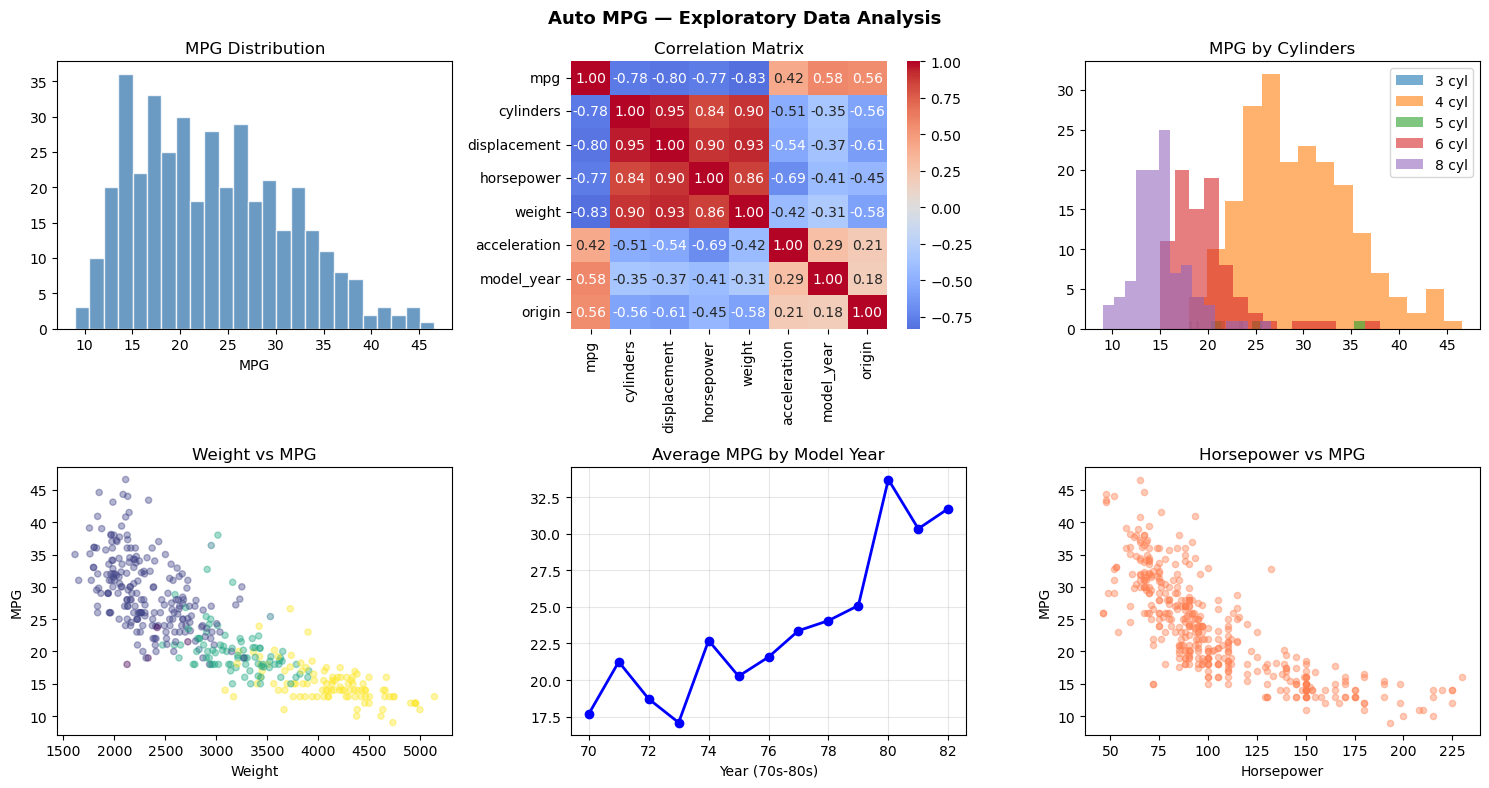

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Auto MPG — Exploratory Data Analysis', fontsize=13, fontweight='bold')

# Target distribution
axes[0,0].hist(df['mpg'], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('MPG Distribution'); axes[0,0].set_xlabel('MPG')

# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, ax=axes[0,1], annot=True, fmt='.2f', cmap='coolwarm', center=0)
axes[0,1].set_title('Correlation Matrix')

# MPG by cylinders
for cyl in sorted(df['cylinders'].unique()):
    mpg_vals = df[df['cylinders']==cyl]['mpg']
    axes[0,2].hist(mpg_vals, alpha=0.6, bins=15, label=f'{int(cyl)} cyl')
axes[0,2].set_title('MPG by Cylinders'); axes[0,2].legend()

# Weight vs MPG
axes[1,0].scatter(df['weight'], df['mpg'], alpha=0.4, s=20, c=df['cylinders'], cmap='viridis')
axes[1,0].set_xlabel('Weight'); axes[1,0].set_ylabel('MPG'); axes[1,0].set_title('Weight vs MPG')

# Year trend
yr_mpg = df.groupby('model_year')['mpg'].mean()
axes[1,1].plot(yr_mpg.index, yr_mpg.values, 'b-o', markersize=6, lw=2)
axes[1,1].set_title('Average MPG by Model Year'); axes[1,1].set_xlabel('Year (70s-80s)')
axes[1,1].grid(True, alpha=0.3)

# Horsepower vs MPG
axes[1,2].scatter(df['horsepower'], df['mpg'], alpha=0.4, s=20, color='coral')
axes[1,2].set_xlabel('Horsepower'); axes[1,2].set_ylabel('MPG'); axes[1,2].set_title('Horsepower vs MPG')

plt.tight_layout()
plt.savefig('DL_19_EDA.png', dpi=150, bbox_inches='tight')
plt.show()



Step 03: Feature Engineering

In [5]:
# Feature engineering
df['power_to_weight']  = df['horsepower'] / df['weight']
df['displacement_per_cyl'] = df['displacement'] / df['cylinders']
df['is_american'] = (df['origin'] == 1).astype(int)

features = ['cylinders','displacement','horsepower','weight','acceleration',
            'model_year','power_to_weight','displacement_per_cyl','is_american']

X = df[features].values
y = df['mpg'].values

# train_test_split only cuts data TWO ways at a time, but we need THREE groups
# (train/val/test) -- so we call it twice, splitting off one piece each time.

# Split 1: carve off the TEST set (20% of everything). This is set aside untouched
# until Step 6 -- nothing in Step 4/5 (hyperparameter search, training) may see it.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# Split 2: take the remaining 80% ("X_tr") and split IT again -- 15% of that 80%
# becomes the VALIDATION set (used in Step 4 to pick hyperparameters + for early
# stopping), the rest becomes the final TRAINING set.
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.15, random_state=42)

# As a share of the ORIGINAL data, this works out to:
#   Test       = 20%
#   Validation = 0.15 * 80% = 12%
#   Train      = 0.85 * 80% = 68%

# Fit the scaler on TRAIN only, then apply it to val/test -- fitting on the full
# dataset would leak val/test statistics into training (data leakage).
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_va_sc = sc.transform(X_va)
X_te_sc = sc.transform(X_te)

print(f'Features: {len(features)} (including 3 engineered)')
print(f'Train: {len(X_tr)}, Val: {len(X_va)}, Test: {len(X_te)}')

Features: 9 (including 3 engineered)
Train: 270, Val: 48, Test: 80


step 04: Hyperparametr Search 

In [6]:
# Small manual hyperparameter search: try a handful of (architecture, dropout, learning
# rate) combos and keep whichever gets the lowest VALIDATION RMSE. In production this
# would be RandomizedSearchCV / KerasTuner / Optuna -- doing it by hand here keeps every
# step visible. We search on a short epoch budget; the winning config gets a full,
# regularized retrain in Step 5.

param_grid = [
    {'units': (64, 32),      'dropout': (0.1, 0.0), 'lr': 0.001},
    {'units': (128, 64),     'dropout': (0.2, 0.1), 'lr': 0.001},
    {'units': (128, 64, 32), 'dropout': (0.2, 0.1), 'lr': 0.001},
    {'units': (128, 64, 32), 'dropout': (0.3, 0.2), 'lr': 0.0005},
    {'units': (256, 128),    'dropout': (0.3, 0.2), 'lr': 0.001},
]

n_in = len(features)

def build_mlp(n_in, units, dropout, lr, use_bn=False, l2=0.0):
    """Build a Dense-only MLP regressor. use_bn/l2 are OFF during the fast search
    and turned ON for the final model, where the longer training budget makes
    the extra regularization worth its cost."""
    reg = keras.regularizers.l2(l2) if l2 > 0 else None
    layers = [keras.layers.Input(shape=(n_in,))]
    for i, u in enumerate(units):
        layers.append(keras.layers.Dense(u, activation='relu', kernel_initializer='he_normal',
                                          kernel_regularizer=reg))
        if use_bn:
            layers.append(keras.layers.BatchNormalization())
        if i < len(dropout):
            layers.append(keras.layers.Dropout(dropout[i]))
    layers.append(keras.layers.Dense(1))  # regression output: no activation
    m = keras.Sequential(layers)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

search_results = []

if TF_AVAILABLE:
    for cfg in param_grid:
        keras.utils.set_random_seed(42)  # same init/shuffle seed across configs -> fair comparison
        m = build_mlp(n_in, cfg['units'], cfg['dropout'], cfg['lr'])
        es = keras.callbacks.EarlyStopping('val_loss', patience=15, restore_best_weights=True)
        h = m.fit(X_tr_sc, y_tr, validation_data=(X_va_sc, y_va),
                  epochs=150, batch_size=32, callbacks=[es], verbose=0)
        val_rmse = float(np.sqrt(min(h.history['val_loss'])))
        search_results.append({**cfg, 'val_rmse': val_rmse})
else:
    from sklearn.neural_network import MLPRegressor
    for cfg in param_grid:
        m = MLPRegressor(hidden_layer_sizes=cfg['units'], activation='relu',
                          learning_rate_init=cfg['lr'], max_iter=300, random_state=42)
        m.fit(X_tr_sc, y_tr)
        val_pred = m.predict(X_va_sc)
        val_rmse = float(np.sqrt(mean_squared_error(y_va, val_pred)))
        search_results.append({**cfg, 'val_rmse': val_rmse})

results_df = pd.DataFrame(search_results).sort_values('val_rmse').reset_index(drop=True)
print('Hyperparameter search results (sorted by validation RMSE):')
print(results_df.to_string(index=False))

# Select by validation RMSE, never by test RMSE -- the test set must stay unseen
# until the single final evaluation in Step 6.
best_cfg = search_results[int(np.argmin([r['val_rmse'] for r in search_results]))]
print(f"\nBest config: units={best_cfg['units']}, dropout={best_cfg['dropout']}, "
      f"lr={best_cfg['lr']} (val RMSE={best_cfg['val_rmse']:.4f})")

Hyperparameter search results (sorted by validation RMSE):
        units    dropout     lr  val_rmse
   (256, 128) (0.3, 0.2) 0.0010  3.444891
    (128, 64) (0.2, 0.1) 0.0010  3.516109
     (64, 32) (0.1, 0.0) 0.0010  3.817662
(128, 64, 32) (0.2, 0.1) 0.0010  3.872472
(128, 64, 32) (0.3, 0.2) 0.0005  4.632293

Best config: units=(256, 128), dropout=(0.3, 0.2), lr=0.001 (val RMSE=3.4449)


Step 5: final Model Training (Best Hyperparamets)

In [7]:
if TF_AVAILABLE:
    # use_bn=True + l2=0.001 add extra overfitting control that we skipped during the
    # search (for speed) but want now that this model trains for up to 500 epochs.
    model = build_mlp(n_in, best_cfg['units'], best_cfg['dropout'], best_cfg['lr'],
                       use_bn=True, l2=0.001)

    callbacks = [
        keras.callbacks.EarlyStopping('val_loss', patience=30, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau('val_loss', factor=0.5, patience=10)
    ]
    history = model.fit(
        X_tr_sc, y_tr, validation_data=(X_va_sc, y_va),
        epochs=500, batch_size=32, callbacks=callbacks, verbose=0
    )
    y_pred = model.predict(X_te_sc, verbose=0).ravel()
    print(f'Training completed: {len(history.history["loss"])} epochs')
else:
    from sklearn.neural_network import MLPRegressor
    model = MLPRegressor(hidden_layer_sizes=best_cfg['units'], activation='relu',
                          learning_rate_init=best_cfg['lr'], max_iter=500, random_state=42)
    model.fit(X_tr_sc, y_tr)
    y_pred = model.predict(X_te_sc)

# Test set is touched exactly once, here -- this is the number we report.
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
mae  = mean_absolute_error(y_te, y_pred)
r2   = r2_score(y_te, y_pred)
print(f'\n=== TEST SET RESULTS (best config) ===')
print(f'RMSE: {rmse:.4f} MPG')
print(f'MAE:  {mae:.4f} MPG')
print(f'R²:   {r2:.4f}')

Training completed: 101 epochs

=== TEST SET RESULTS (best config) ===
RMSE: 2.3603 MPG
MAE:  1.6512 MPG
R²:   0.8964


Step 06: Evaluation & Visulization

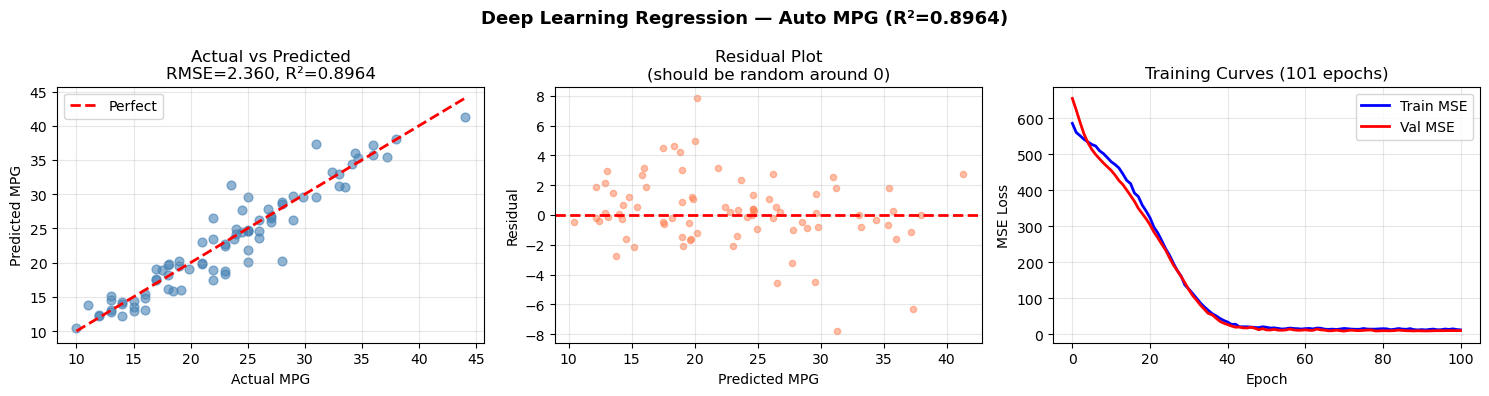

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Deep Learning Regression — Auto MPG (R²={r2:.4f})', fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_te, y_pred, s=40, alpha=0.6, color='steelblue')
min_v, max_v = min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())
axes[0].plot([min_v,max_v],[min_v,max_v],'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Actual MPG'); axes[0].set_ylabel('Predicted MPG')
axes[0].set_title(f'Actual vs Predicted\nRMSE={rmse:.3f}, R²={r2:.4f}'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
resid = y_te - y_pred
axes[1].scatter(y_pred, resid, s=20, alpha=0.5, color='coral')
axes[1].axhline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted MPG'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot\n(should be random around 0)')
axes[1].grid(True, alpha=0.3)

# Training history
if TF_AVAILABLE and 'history' in dir():
    axes[2].plot(history.history['loss'],     'b-', lw=2, label='Train MSE')
    axes[2].plot(history.history['val_loss'], 'r-', lw=2, label='Val MSE')
    axes[2].set_title(f'Training Curves ({len(history.history["loss"])} epochs)')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MSE Loss')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
else:
    axes[2].bar(['RMSE','MAE'], [rmse, mae], color=['#3498db','#27ae60'], edgecolor='black')
    axes[2].set_title('Error Metrics'); axes[2].set_ylabel('Error (MPG)')
    for i, v in enumerate([rmse, mae]):
        axes[2].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('DL_19_Project_Results.png', dpi=150, bbox_inches='tight')
plt.show()

Deployement-Ready 

In [9]:
import os, json
try:
    import joblib #is used to save phthon object like the trained model and scaler
    #if joblib is not availble, python falls back to pickle 
except ImportError:
    import pickle as joblib  # fallback: pickle exposes dump()/load() with the same call shape we use below

MODEL_DIR = 'dl19_mpg_deployment' #model_dir is the folder where we will store the saved files
os.makedirs(MODEL_DIR, exist_ok=True) #create the folder if it does not already exist

# 1. Persist the scaler -- inference MUST reuse the exact train-time mean/std,
#    never refit on new data, or predictions silently drift off distribution.
joblib.dump(sc, f'{MODEL_DIR}/scaler.pkl') #sc is the standarscaler object that was fitted on the training data
#joblib.dump() store this scaler into a filed called : dl19_mpg_deployment
#why this is important 
#During predition, we must use the same scaling that was used during training. 
#if we refit the scaler again on new data. the predication may become inconsistent

# 2. Persist the trained model itself
if TF_AVAILABLE:
    model.save(f'{MODEL_DIR}/mpg_mlp_model.keras')
else:
    joblib.dump(model, f'{MODEL_DIR}/mpg_mlp_model.pkl')

# 3. Persist metadata: feature order + engineering formulas + the metrics this
#    model shipped with, so a future retrain has a documented baseline to beat.
metadata = {
    'features': features,
    'engineered_features': {
        'power_to_weight': 'horsepower / weight',
        'displacement_per_cyl': 'displacement / cylinders',
        'is_american': 'int(origin == 1)'
    },
    'best_hyperparameters': {k: v for k, v in best_cfg.items() if k != 'val_rmse'},
    'test_metrics': {'rmse': float(rmse), 'mae': float(mae), 'r2': float(r2)}
}
with open(f'{MODEL_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved model, scaler, and metadata to ./{MODEL_DIR}/')


def predict_mpg(raw: dict) -> float:
    """Deployment-ready inference: takes raw car specs (not engineered features),
    reproduces the exact feature-engineering steps from Step 3, scales with the
    fitted scaler, and returns a single MPG prediction. This is the function a
    FastAPI/Flask endpoint would call directly."""
    row = {
        'cylinders': raw['cylinders'],
        'displacement': raw['displacement'],
        'horsepower': raw['horsepower'],
        'weight': raw['weight'],
        'acceleration': raw['acceleration'],
        'model_year': raw['model_year'],
    }
    # Recompute the same engineered features as training -- inference must mirror
    # training feature engineering exactly, or the model sees an unseen distribution.
    row['power_to_weight'] = row['horsepower'] / row['weight']
    row['displacement_per_cyl'] = row['displacement'] / row['cylinders']
    row['is_american'] = int(raw.get('origin', 1) == 1)

    x = np.array([[row[f] for f in features]])
    x_scaled = sc.transform(x)

    if TF_AVAILABLE:
        pred = model.predict(x_scaled, verbose=0).ravel()[0]
    else:
        pred = model.predict(x_scaled)[0]
    return float(pred)


# Demo: a 1980s 4-cylinder economy car
sample = {'cylinders': 4, 'displacement': 120, 'horsepower': 88, 'weight': 2400,
          'acceleration': 15.5, 'model_year': 80, 'origin': 3}
print(f"\nSample prediction: {predict_mpg(sample):.2f} MPG")

print("""
Deployment checklist:
  - Validate raw inputs (ranges, types, missing fields) before calling predict_mpg()
  - Reload the scaler + model from disk in the serving process -- never refit them
  - Log prediction inputs/outputs for drift monitoring
  - Pin library versions (tensorflow/scikit-learn) to match the training environment
""")


Saved model, scaler, and metadata to ./dl19_mpg_deployment/

Sample prediction: 30.71 MPG

Deployment checklist:
  - Validate raw inputs (ranges, types, missing fields) before calling predict_mpg()
  - Reload the scaler + model from disk in the serving process -- never refit them
  - Log prediction inputs/outputs for drift monitoring
  - Pin library versions (tensorflow/scikit-learn) to match the training environment

